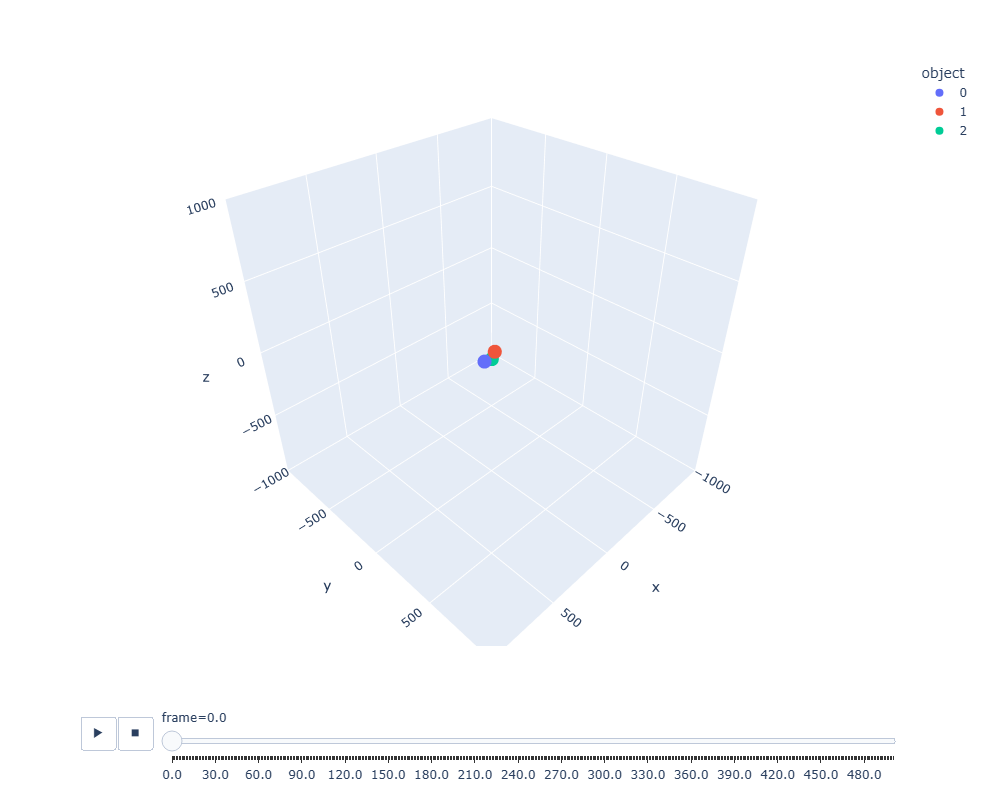

In [1]:
import numpy as np
import plotly.express as px
import pandas as pd

N = 3 #Number of objects
Time = 250 #Duration of the simulation
frame_skip = 50 #Number of timesteps between frames

M = 100 #Mass Multiplier [M=1, objects will have a mass between 0 and 1]
R = 100 #Intital Postition Multiplier [R=1, objects will be randomly placed in a 1x1x1 cube]
vm = 1.5 #Velocity Multiplier [vm=1, objects will have a velocity between 0 and 1 in each direction]
soft_len = 0.1 #Softening Length to prevent singularities in force calculations when objects get very close to each other
G = 1 #Gravitational Constant (set to 1 for simplicity, can be changed to real value if desired)

dt = 0.01 #Timestep
t = 0 #Intializing time
frames = [] #Setting the empty frame list
frame_num = 0 #Intializing frame number

#Setting array of objects: 
    #col 0,1,2 stores position in x,y,z directions
    #col 3 stores mass
    #col 4,5,6 stores momentum in x,y,z directions
    #col 7,8,9 stores force on the object in x,y,z directions
objects = np.zeros([N,10])

#Gives objects a random initial position, mass, and momentum
for i in range(N):
    objects[i,0:3] = R * np.array((np.random.random(),np.random.random(),np.random.random()))
    objects[i,3] = M * (1 - np.random.random()) #(1-random.random()) since random.random() returns values on the interval [0.0, 1.0)
    objects[i,4:7] = vm * objects[i,3] * np.array((np.random.random(),np.random.random(),np.random.random()))

#Main simulation loop
while t<Time:
    #Sets force equal to 0
    objects[:,7:10] = 0
    
    #Records current object position and frame
    if frame_num % frame_skip == 0:
        for i in range(N):
            frames.append((objects[i,0], objects[i,1], objects[i,2], str(i), frame_num/frame_skip))
    
    #Calculating the force between every object
    for i in range(N):
        for j in range(i+1,N):
            if i != j:
                r = objects[j,0:3] - objects[i,0:3]
                r_dot = np.dot(r,r)
                
                F = G * objects[i,3] * objects[j,3] * (r / (r_dot + soft_len**2)**1.5)
                
                objects[i,7:10] += F
                objects[j,7:10] -= F
    
    #Updating momentum
    objects[:,4:7] += objects[:,7:10] * dt
    
    #Updating Position
    for i in range(N): #Put in for loop so that mass is a scalar instead of an array of different shape from momentum. [find better solution?]
        objects[i,0:3] += (objects[i,4:7] / objects[i,3]) * dt
    
    t += dt
    frame_num += 1

#Converting saved position data into a format that px.scatter_3d can use
df = pd.DataFrame(frames, columns=['x','y','z','object','frame'])

fig = px.scatter_3d(
    df,
    x='x',
    y='y',
    z='z',
    color='object',
    animation_frame='frame',
    width=800, 
    height=800,
)

fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 10
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 1

fig.update_layout(
    scene=dict(
        xaxis=dict(range=[-10*R, 10*R]),
        yaxis=dict(range=[-10*R, 10*R]),
        zaxis=dict(range=[-10*R, 10*R]),
        aspectmode='cube'
    )
)

fig.show()